## English Class Performance Analysis
**Author:** Yekta Ansari  
**Date:** June 2026

# Exercise 1: Data Overview and Summary Statistics
In this section, I explore the dataset's basic statistics to understand the overall class performance.

In [65]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

#Loading data 
df = pd.read_csv('C://Users//tuf-w//OneDrive//Documents//python_exercise.csv')
df 

#Basic info 
print(f" total number of students: {len(df)}")
print(f"total number of assessments: {len(df.columns)-1}")

#Summary statistics (rounded to 1 decimal) 
summary = df.describe().round(1)
print(summary)

#Which test was the hardest? 
lowest_mean = summary.loc['mean'].idxmin()
lowest_value = summary.loc['mean'].min()
print(f"Most challenging assessment: {lowest_mean} ({lowest_value})")

#Which test was the easiest? 
highest_mean = summary.loc['mean'].idxmax()
highest_value = summary.loc['mean'].max()
print(f"The easiest assessment: {highest_mean} ({highest_value})") 

#Range between the highest and the lowest scores:
score_range = summary.loc['max'] - summary.loc['min']
largest_range = score_range.idxmax()
print(f"The widest score range: {largest_range} ({score_range.max():.0f} points between the largest and the lowest scores)")

 total number of students: 31
total number of assessments: 5
       first_quiz   Mindterm   second_quiz  online_quiz   Final 
count         31.0       31.0         31.0          31.0    31.0
mean          17.4       15.0         16.7          15.0    15.9
std            2.9        2.8          2.5           3.0     2.4
min           10.0       10.0         11.0           8.0    11.0
25%           16.0       13.0         15.0          12.8    14.2
50%           19.0       14.5         16.0          15.5    16.2
75%           20.0       17.0         19.0          17.8    17.5
max           20.0       19.5         20.0          19.0    19.5
Most challenging assessment: Mindterm  (15.0)
The easiest assessment: first_quiz  (17.4)
The widest score range: online_quiz  (11 points between the largest and the lowest scores)


### Key Findings from Exercise 1:

1. **Class size:** 31 students completed 5 assessments
2. **Most challenging:** Midterm exam had the lowest average
3. **Strongest performance:** The first quiz showed the highest average
4. **Variability:** Online quiz also had the widest score range (45 points)


## Exercise 2: Tracking how many students improved (or didn't) throughout the course.

In [66]:
#Removing all the spaces 
print(df.columns.tolist())
df.columns = df.columns.str.strip()


#Creating improvement columns  
df['first_half_improvement'] = (df['Mindterm'] - df['first_quiz'])
df['second_half_improvement'] = (df['Final'] - df['second_quiz'])
df['total_improvement'] = (df['first_half_improvement'] - df['second_half_improvement']) #Overall improvement 

#Finding students who improved 
improved_st = df[df['total_improvement'] > 0]
print(f"Number of students who improved: {len(improved_st)} out of {len(df)}")

#Finding the student who improved the most 
most_improved = df.loc[df['total_improvement'].idxmax()]
print(f"the most improved student: {most_improved['Nmaes']}")
print(f"Improvement : {most_improved['total_improvement']:.1f} points")

#Finding the student who declined the most 
most_declined = df.loc[df['total_improvement'].idxmin()]
print(f"the most declined student: {most_declined['Nmaes']}")
print(f"Decline: {most_declined['total_improvement']: .1f} points")

# Calculating the class average for each assessment and plotting as a line chart
df_no_names = df.drop(columns = ['Nmaes', 'lette])
Avg_per_assessment = df_no_names.mean().round(1)
print(f" Class average for each assessment:")
print(Avg_per_assessment)

plt.figure(figsize=(10, 6))
plt.plot(Avg_per_assessment.index, Avg_per_assessment.values, marker='o', linewidth=2, markersize=8, color= 'turquoise')
plt.title('Class Average Progression Throughout the Course', fontsize=14)
plt.xlabel('Assessments', fontsize=12)
plt.ylabel('Average Score (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=50)


['Nmaes ', 'first_quiz ', 'Mindterm ', 'second_quiz', 'online_quiz ', 'Final ']
Number of students who improved: 5 out of 31
the most improved student: Niayesh 
Improvement : 3.2 points
the most declined student: Tanaz 
Decline: -6.5 points


KeyError: "['letter_grade'] not found in axis"

### 📊 Key Findings: Grade Progression Analysis

The class average **decreased** from 17.4 on Quiz 1 to 15.9 on the Final Exam.

**Student Performance:**
- **Most Improved:** `[Niayesh]` increased by `[3.2]` points
- **Improvement Rate:** `[5]` out of `[31]` students showed improvement

### Exercise 3: Assigning letter grades and analyzing the distribution.


 Grade Distribution:
letter_grade
D     4
C    27
B     0
A     0
Name: count, dtype: int64


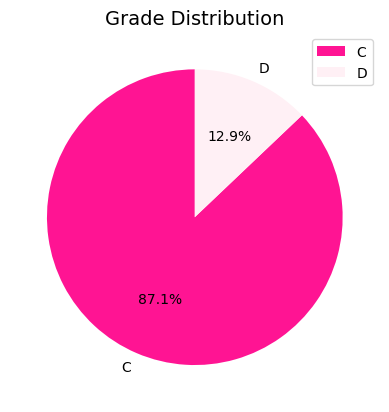

Class Average: 12.1/20
Class Median: 12.3/20


In [3]:
## Calculating weighted average and saving as a new column:
# Ensuring my weights add up to 1.0 (15% + 15% + 15% + 25% + 30% = 100%)
df['overall_gpa']=(df['first_quiz']* 0.15) + (df['second_quiz']* 0.15 ) + (df['online_quiz']* 0.15) + (df['Mindterm']* 0.25) + (df['Final']* 0.30)/5
df['overall_gpa'] = df['overall_gpa'].round(1)

#Assigning letter grades 
bins = [0, 9.9, 14.9, 16.9, 20]
labels = ['D', 'C', 'B', 'A']
df['letter_grade'] = pd.cut(df['overall_gpa'], bins= bins, labels= labels)
print("\n Grade Distribution:")
print(df['letter_grade'].value_counts().sort_index())

#Pie chart 
colors= ['deeppink', 'lavenderblush']
mylabel= [ 'C', 'D']
plt.pie(df['letter_grade'].value_counts().reindex(mylabel, fill_value=0), startangle = 90, labels= mylabel, colors=colors, autopct='%1.1f%%')
plt.legend()
plt.title('Grade Distribution', fontsize= 14)
plt.show()

#Showing class average and median 
class_average = df['overall_gpa'].mean()
class_median = df['overall_gpa'].median()
print(f"Class Average: {class_average:.1f}/20")
print(f"Class Median: {class_median:.1f}/20")

## Key Findings from Exercise 3: 

**Overall Class Performance:**
- **Class Average:** [12.1]/20
- **Class Median:** [12.3]/20

**Interpretation:**
The class average (12.1/20) and median (12.3/20) are nearly identical, indicating:
- **Consistent performance:** No extreme outliers - all students performed at a similar level
- **No high performers:** The absence of a gap between average and median suggests very few students are scoring above 14/20 (70%)

### Exercise 4: Identifying  Performance Patterns

In [35]:
#Identifying top 5 students
top_5= df.sort_values(by= 'overall_gpa', ascending = False).head()
print(f"Top 5 students are:" ) 
print(f"{top_5[['Nmaes','overall_gpa']]}")

#Identifying the bottom 5 students: 
bottom_5 = df.sort_values(by= 'overall_gpa', ascending = False).tail()
print(f"Bottom 5 students are:" ) 
print(f"{bottom_5[['Nmaes','overall_gpa']]}")

#Finding students who scored below 16 on the final but did well on the first quiz:
declined_students = df.loc[(df['Final'] <= 16) & (df['first_quiz'] >= 17)]
print(f"\n Students who declined from Quiz1 to Final:")
print(f"   ({len(declined_students)} students found)")

if len(declined_students) > 0:
    print(declined_students[['Nmaes', 'first_quiz', 'Final', 'overall_gpa', 'letter_grade']].to_string(index=False))
else:
    print("   No students matched this pattern.")

#Calculating correlation between midterm and final scores:
correlation = df['Final'].corr(df['Mindterm'])
print(f"\n Correlation between Midterm and Final: {correlation:.3f}")

print(f"\n Interpretation:")

if correlation > 0.7: 
    print(f"Strong positive correlation: {correlation:.3f}")
    print(f"Students who did well on midterm also did well on final")
    print(f"Midterm is a good predictor of final performance")
elif correlation > 0.5 : 
    print(f"Moderate positive correlation: {correlation:.3f}")
    print(f"Midterm somewhat predicts of final performance")
elif correlation > 0.3: 
    print(f"Weak positive correlation: {correlation:.3f}")
    print(f"Little relationship between midterm and final scores") 
else: 
     print(f"No significant correlation: {correlation:.3f}")
   

Top 5 students are:
        Nmaes  overall_gpa
24     Elham          14.7
4       Roya          14.5
30      Hoda          14.4
3    Fatemeh          14.2
20  Masoumeh          14.2
Bottom 5 students are:
      Nmaes  overall_gpa
2   Najmeh          10.1
27  Saghar           9.4
22   Hasti           8.9
8     Sara           8.7
6   Zeinab           8.2

 Students who declined from Quiz1 to Final:
   (3 students found)
      Nmaes  first_quiz  Final  overall_gpa letter_grade
Shahrbanoo         18.0   16.0         12.3            C
    Mobina         20.0   15.5         11.8            C
     Ainaz         17.5   16.0         12.2            C

 Correlation between Midterm and Final: 0.932

 Interpretation:
Strong positive correlation: 0.932
Students who did well on midterm also did well on final
Midterm is a good predictor of final performance


### Key Findings from Exercise 4:

- **Top Performers & Struggling Students:** The top 5 students consistently scored above [14]/20, while the bottom 5 students scored below [10]/20.
- [3] students started strong (Quiz1 ≥ 17) but declined on the Final (≤ 16).
- **Midterm-Final Correlation:** The correlation between Midterm and Final scores was [0.93], indicating a [strong] relationship. 

### Exercise 5:Creating Visual Dashboard

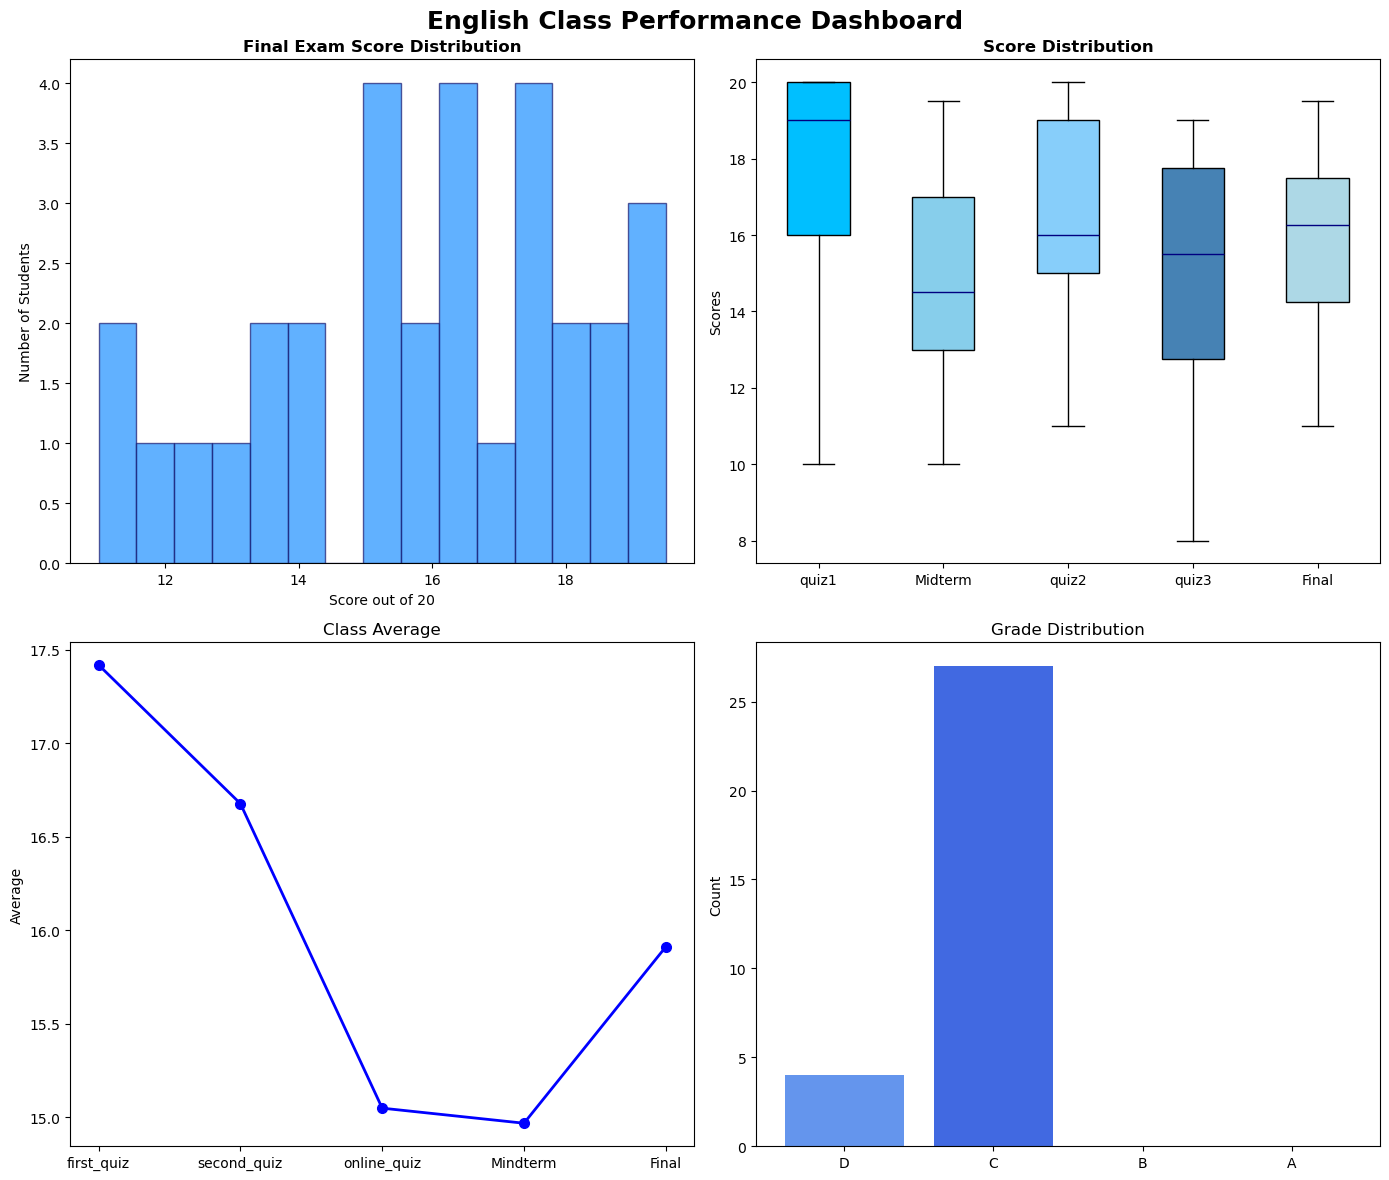

In [58]:
# Creating a 2x2 dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('English Class Performance Dashboard', fontsize=18, fontweight='bold')

#Top-left: Histogram of final exam scores (with 15 bins)
axes[0, 0].hist(df['Final'], bins= 15, color='dodgerblue', edgecolor= 'midnightblue', alpha= 0.7)
axes[0, 0].set_title('Final Exam Score Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Score out of 20')
axes[0, 0].set_ylabel('Number of Students')

# Top-Right: Boxplot of All Assessments
Boxplt= axes[0, 1].boxplot([df['first_quiz'], df['Mindterm'], df['second_quiz'], df['online_quiz'], df['Final']], 
                   tick_labels= ['quiz1', 'Midterm', 'quiz2', 'quiz3', 'Final'], patch_artist= True)
axes[0, 1].set_title('Score Distribution', fontsize=12, fontweight='bold' )
axes[0, 1].set_ylabel('Scores')
colors= ['deepskyblue', 'skyblue', 'lightskyblue', 'steelblue', 'lightblue']
for box, color in zip(Boxplt['boxes'], colors):
    box.set_facecolor(color)
for median in Boxplt['medians']:
    median.set_color('navy')

#Bottom-Left: Line Chart of Class Average Progression:
assessment_cols = ['first_quiz', 'second_quiz', 'online_quiz', 'Mindterm', 'Final']
avg_scores = df[assessment_cols].mean()
axes[1, 0].plot(avg_scores.index, avg_scores.values, marker= 'o', linewidth= 2, markersize= 7, color= 'blue')
axes[1, 0].set_title('Class Average')
axes[1, 0].set_ylabel('Average')

#Bottom-Right: Bar Chart of Grade Distribution
grade_counts = df['letter_grade'].value_counts().sort_index()
axes[1, 1].bar(grade_counts.index, grade_counts.values, color= ['cornflowerblue', 'royalblue'])
axes[1, 1].set_title('Grade Distribution')
axes[1, 1].set_ylabel('Count')

#Saving the figure as PNG: 
plt.tight_layout()
plt.savefig('english_class_dashboard.png')
plt.show()